## Step 1: Exploratory Data Analysis (EDA) & Data Auditing

- Task 1.1: Load the dataset and inspect its shape, columns and data types

In [1]:
import pandas as pd

# Load Dataset
df = pd.read_csv("C:/Users/win 11/Downloads/AB_NYC_2019.csv/AB_NYC_2019.csv")

# First 5 rows
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [2]:
# Shape of dataset
df.shape

(48895, 16)

In [3]:
# Column names
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [4]:
# Data types
df.dtypes

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

In [6]:
# Complete information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

- Task 1.2: Identify Numerical and Categorical Columns

In [5]:
# Numerical Columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
print("Numerical Columns:")
print(num_cols)

Numerical Columns:
Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')


In [6]:
# Categorical Columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:")
print(cat_cols)

Categorical Columns:
Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'last_review'],
      dtype='object')


- Task 1.3: Check Missing Values

In [7]:
# Missing values
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [12]:
# Missing value percentage
missing = (df.isnull().sum()/len(df))*100
missing.sort_values(ascending=False)

last_review                       20.558339
reviews_per_month                 20.558339
host_name                          0.042949
name                               0.032723
neighbourhood_group                0.000000
neighbourhood                      0.000000
id                                 0.000000
host_id                            0.000000
longitude                          0.000000
latitude                           0.000000
room_type                          0.000000
price                              0.000000
number_of_reviews                  0.000000
minimum_nights                     0.000000
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64

## Step 2: Data Cleaning & Handling Missing Values

- Task 2.1: Handle last_review Column

In [10]:
# Check missing values
df["last_review"].isnull().sum()

np.int64(10052)

In [11]:
# Drop last_review column
df.drop("last_review", axis=1, inplace=True)

- Task 2.2: Handle reviews_per_month

In [14]:
# Check missing values
df["reviews_per_month"].isnull().sum()

np.int64(10052)

In [15]:
# Check why values are missing
df[df["reviews_per_month"].isnull()][["number_of_reviews", "reviews_per_month"]].head()

,number_of_reviews,reviews_per_month
2,0,NaN
19,0,NaN
26,0,NaN
36,0,NaN
38,0,NaN


In [16]:
df["reviews_per_month"].fillna(0, inplace=True)

C:\Users\win 11\AppData\Local\Temp\ipykernel_12264\1901275697.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["reviews_per_month"].fillna(0, inplace=True)


In [17]:
# Verify
df["reviews_per_month"].isnull().sum()

np.int64(0)

- Task 2.3: Drop Irrelevant Columns

In [18]:
# Drop unnecessary columns
df.drop(["id", "host_id", "name", "host_name"], axis=1, inplace=True)

In [19]:
df.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [20]:
df.isnull().sum()

neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

## Step 3: Outlier Identification & Treatment

- Task 3.1: Detect Outliers using Boxplot and Histogram

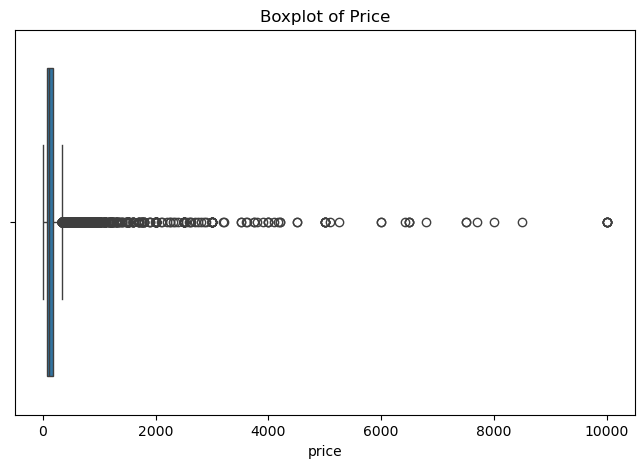

In [21]:
# Code 1: Boxplot for price
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df["price"])
plt.title("Boxplot of Price")
plt.show()

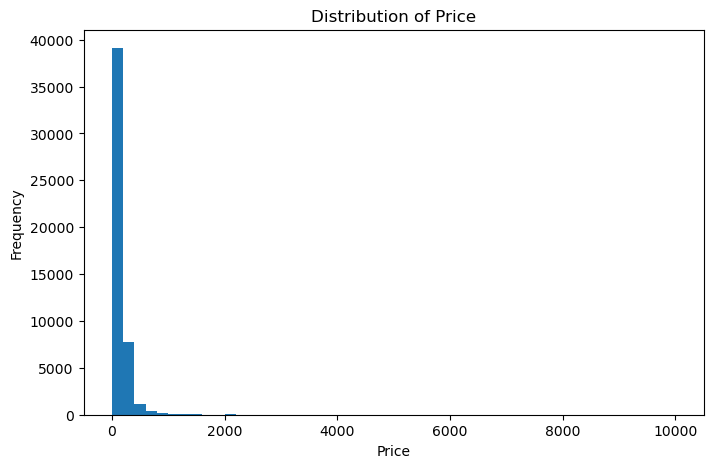

In [22]:
# Code 2: Histogram for price
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=50)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

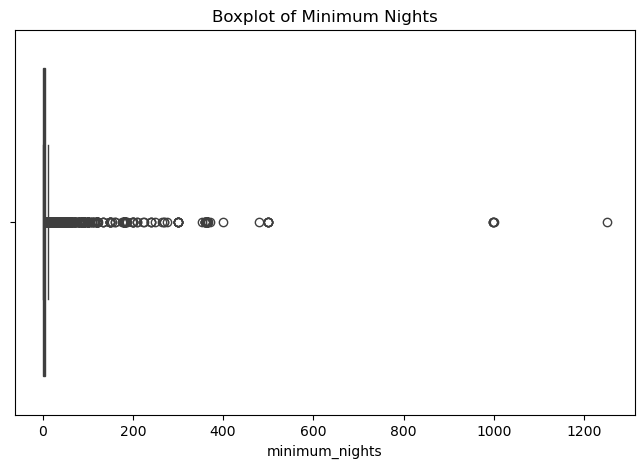

In [23]:
# Code 3: Boxplot for minimum_nights
plt.figure(figsize=(8,5))
sns.boxplot(x=df["minimum_nights"])
plt.title("Boxplot of Minimum Nights")
plt.show()

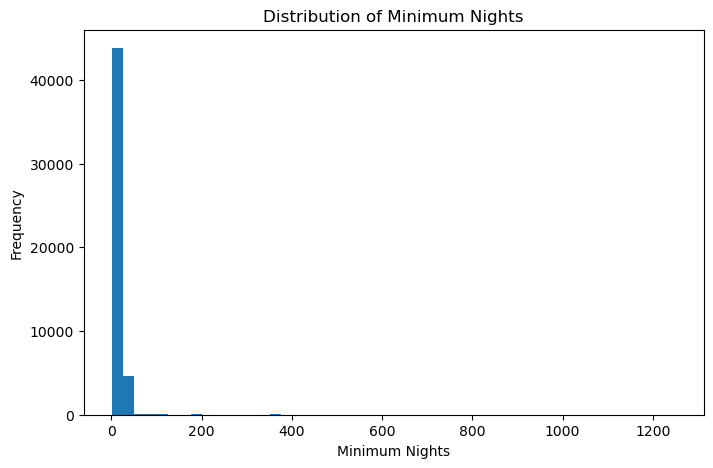

In [24]:
# Code 4: Histogram for minimum_nights
plt.figure(figsize=(8,5))
plt.hist(df["minimum_nights"], bins=50)
plt.title("Distribution of Minimum Nights")
plt.xlabel("Minimum Nights")
plt.ylabel("Frequency")
plt.show()

- Task 3.2: Remove Outliers using 95th Percentile

In [25]:
# Code 1: Find 95th Percentile
price_limit = df["price"].quantile(0.95)
minimum_limit = df["minimum_nights"].quantile(0.95)

print(price_limit)
print(minimum_limit)

355.0
30.0


In [26]:
# Code 2: Remove Outliers
df = df[
    (df["price"] <= price_limit) &
    (df["minimum_nights"] <= minimum_limit)
]

In [27]:
# Code 3: Check New Shape
df.shape

(45759, 11)

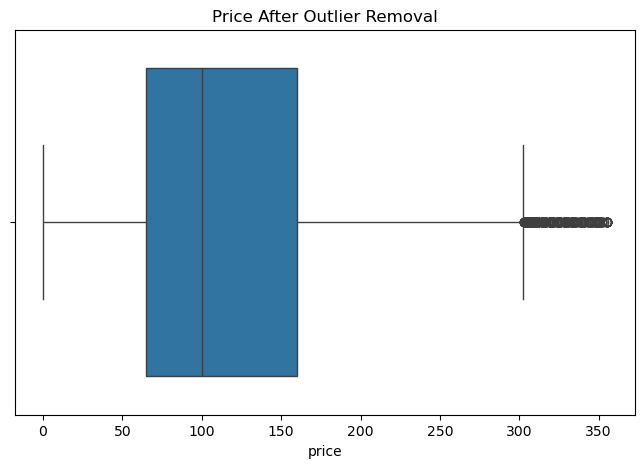

In [28]:
# Code 4: Verify using Boxplots
plt.figure(figsize=(8,5))
sns.boxplot(x=df["price"])
plt.title("Price After Outlier Removal")
plt.show()

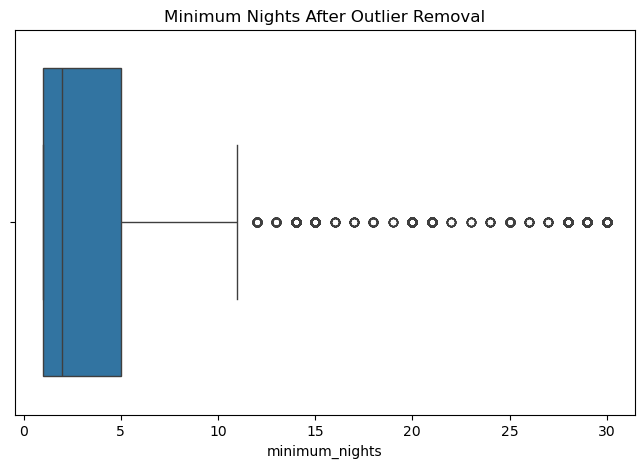

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["minimum_nights"])
plt.title("Minimum Nights After Outlier Removal")
plt.show()

## Step 4: Feature Selection & Categorical Encoding

- Task 4.1: Address High Cardinality

In [30]:
# Code 1: Check Unique Values
print("Neighbourhood Unique Values:", df["neighbourhood"].nunique())
print("Neighbourhood Group Unique Values:", df["neighbourhood_group"].nunique())

Neighbourhood Unique Values: 219
Neighbourhood Group Unique Values: 5


In [31]:
# Code 2: Drop neighbourhood
df.drop("neighbourhood", axis=1, inplace=True)

- Task 4.2: One-Hot Encoding

In [32]:
df = pd.get_dummies(
    df,
    columns=["neighbourhood_group", "room_type"],
    drop_first=True
)

In [33]:
df.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,40.64749,-73.97237,149,1,9,0.21,6,365,True,False,False,False,True,False
1,40.75362,-73.98377,225,1,45,0.38,2,355,False,True,False,False,False,False
2,40.80902,-73.94190,150,3,0,0.00,1,365,False,True,False,False,True,False
3,40.68514,-73.95976,89,1,270,4.64,1,194,True,False,False,False,False,False
4,40.79851,-73.94399,80,10,9,0.10,1,0,False,True,False,False,False,False


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45759 entries, 0 to 48894
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   latitude                           45759 non-null  float64
 1   longitude                          45759 non-null  float64
 2   price                              45759 non-null  int64  
 3   minimum_nights                     45759 non-null  int64  
 4   number_of_reviews                  45759 non-null  int64  
 5   reviews_per_month                  45759 non-null  float64
 6   calculated_host_listings_count     45759 non-null  int64  
 7   availability_365                   45759 non-null  int64  
 8   neighbourhood_group_Brooklyn       45759 non-null  bool   
 9   neighbourhood_group_Manhattan      45759 non-null  bool   
 10  neighbourhood_group_Queens         45759 non-null  bool   
 11  neighbourhood_group_Staten Island  45759 non-null  bool   


## Step 5: Feature-Target Separation & Validation Split

- Task 5.1: Separate Features (X) and Target (y)

In [35]:
# Features
X = df.drop("price", axis=1)

# Target
y = df["price"]

In [36]:
X.head()

,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,40.64749,-73.97237,1,9,0.21,6,365,True,False,False,False,True,False
1,40.75362,-73.98377,1,45,0.38,2,355,False,True,False,False,False,False
2,40.80902,-73.94190,3,0,0.00,1,365,False,True,False,False,True,False
3,40.68514,-73.95976,1,270,4.64,1,194,True,False,False,False,False,False
4,40.79851,-73.94399,10,9,0.10,1,0,False,True,False,False,False,False


In [37]:
y.head()

0    149
1    225
2    150
3     89
4     80
Name: price, dtype: int64

In [38]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (45759, 13)
Shape of y: (45759,)


- Task 5.2: Split Dataset into Training and Testing Sets

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42)

In [40]:
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (36607, 13)
X_test : (9152, 13)
y_train : (36607,)
y_test : (9152,)


## Step 6: Model Training & Evaluation

- Task 6.1: Train the Linear Regression Model

In [41]:
from sklearn.linear_model import LinearRegression

# Create Model
model = LinearRegression()

# Train Model
model.fit(X_train, y_train)

LinearRegression()

- Task 6.2: Predict Prices on Test Data

In [42]:
# Predict
y_pred = model.predict(X_test)

In [43]:
prediction = pd.DataFrame({"Actual Price": y_test.values,"Predicted Price": y_pred})
prediction.head(10)

,Actual Price,Predicted Price
0,132,173.319992
1,250,157.350885
2,350,173.114638
3,250,182.657475
4,199,186.310116
5,139,165.571735
6,150,128.755274
7,55,59.739924
8,184,191.656805
9,129,99.050735


- Task 6.3: Calculate Evaluation Metrics

In [44]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Evaluation Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2 Score :", r2)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)

R2 Score : 0.4708277350002139
MAE : 38.5408749155396
MSE : 2834.959378892641
RMSE : 53.24433658984438


## Step 7: Residual Analysis & Interpretation

- Task 7.1: Plot Actual Prices vs Predicted Prices

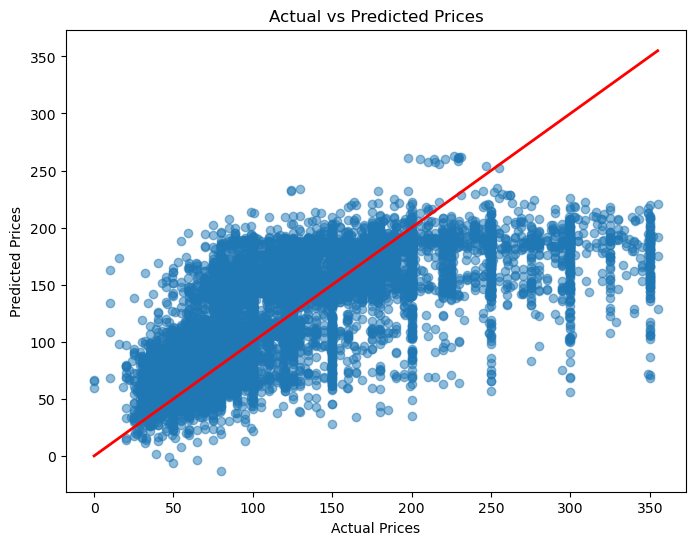

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)

# 45° Diagonal Line
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color='red',linewidth=2)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

- Task 7.2: Residual Plot & Error Distribution

In [48]:
residuals = y_test - y_pred

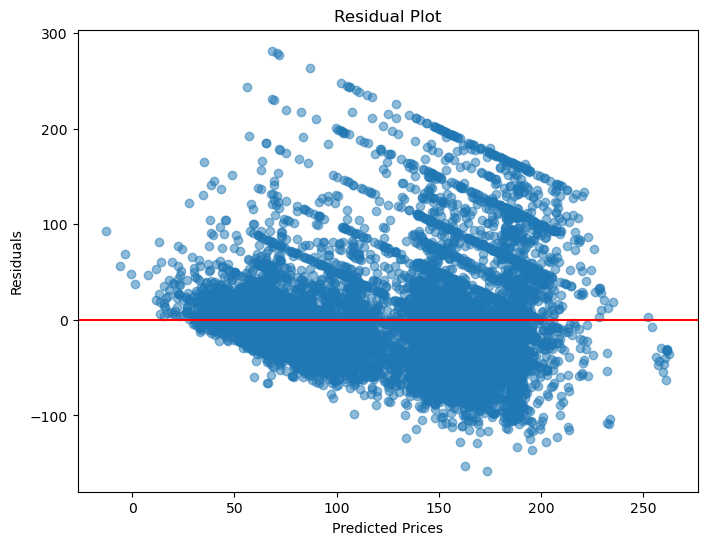

In [49]:
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

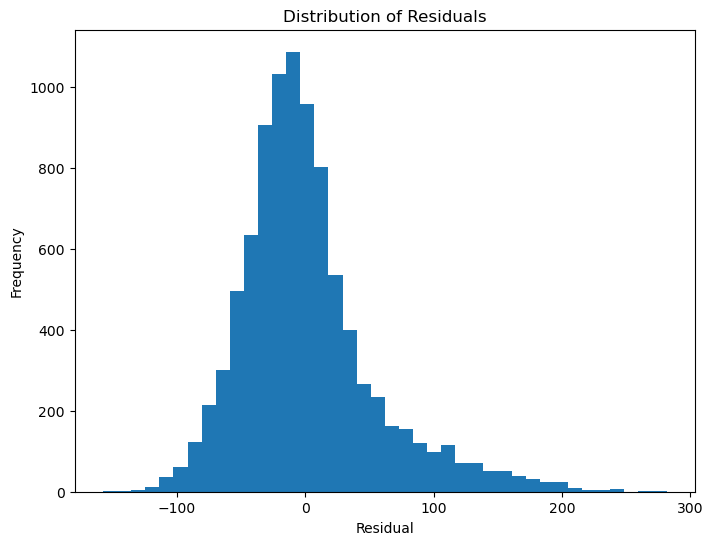

In [50]:
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=40)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

#### Task 7.3: Final Interpretation

Question: 
> Does the model perform better on cheap listings or expensive listings, and why?

Answer:
> The Linear Regression model generally performs better on cheap and medium-priced listings than on expensive listings.

Reason:
- Cheap and medium-priced listings are more common in the dataset, so the model learns their patterns more effectively.
- Expensive listings are fewer in number and have much greater price variation.
- As a result, the model finds it difficult to predict the prices of luxury properties accurately.
- Even after removing outliers, predicting expensive listings remains more challenging because of their complex pricing patterns.

## Overall Project Conclusion

- Loaded and explored the Airbnb dataset.
- Handled missing values and removed unnecessary columns.
- Identified and removed outliers.
- Converted categorical variables into numerical format using One-Hot Encoding.
- Split the dataset into training and testing sets.
- Trained a Linear Regression model and generated price predictions.
- Evaluated the model using R² Score, MAE, MSE, and RMSE.
- Based on the residual analysis, concluded that the model provides better predictions for cheap and medium-priced Airbnb listings, while prediction errors are relatively higher for expensive listings due to greater price variability.